
# 🧪 Lab 2 — Temperature & Diversity Mini-Experiment
*(Compare model outputs across temperatures)*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/labs/probability_lab.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

In this lab, you’ll explore how **temperature** affects the behavior of a large language model (LLM). You’ll design and run a small experiment to measure **diversity** in model outputs at different temperatures.

---



## 🎯 Learning Goals

By the end of this lab, you should be able to:

1. Explain what “temperature” means in probabilistic sampling.
2. Generate multiple model outputs with varying temperature.
3. Define and compute a simple **diversity metric**.
4. Compare how diversity changes as temperature increases.
5. Summarize your findings using the **scientific process**.


In [ ]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append("/content/main")
from course_utils import lab2_setup, lab2_generate_samples, lab2_measure_diversity, lab2_build_demo

lab2_setup()
print("✅ Environment ready!")

Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
✅ LAB2_colab_bootstrap complete — scientific libraries ready, helper function loaded.
✅ Environment ready!



## 🧩 Pre-Lab Questions

Answer in 1–2 sentences each:

1. In your own words, what does “temperature” control in an LLM?  
2. What do you predict will happen if we raise the temperature from 0.3 → 1.0 → 2.0?  
3. How would you define “diversity” in text outputs?  

> ✏️ *Edit this cell and write your answers below each question.*



## 🧭 Scientific Process

**Question:**  
If we increase temperature, how does the *diversity* of generated text outputs change?

**Hypothesis:**  
I expect that higher temperature will increase diversity (more varied wording or ideas) because the model will sample from lower-probability tokens more often.

**Experiment Plan:**  
1. Choose a single fixed prompt (e.g., “Describe a sunrise.”).  
2. Generate 5–10 outputs at each temperature (0.3, 1.0, 2.0).  
3. Record the results in a list or table.  
4. Compute a simple diversity metric for each temperature.  
5. Compare and visualize results.

**Measurement (Metric):**  
- **Diversity Index = (unique outputs) / (total outputs)**  

**Expected Shape:**  
Diversity should increase with temperature — low T gives similar outputs, high T gives more variety.



## 🔹 Part 1 — Generate Outputs Across Temperatures

We’ll use the helper function `lab2_generate_samples(prompt, temperatures, n_per_temp)`  
to collect model outputs across different temperatures.


In [ ]:
prompt = "Describe a sunrise in one sentence."
temperatures = [0.3, 1.0, 2.0]

# TODO: Adjust number of samples per temperature (suggested: 5–10)
n_per_temp = 5

results = lab2_generate_samples(prompt, temperatures, n_per_temp)

# Display a few results
for r in results[:10]:
    print(f"T={r['temperature']}: {r['output']}\n")

T=0.3: The horizon blushes with hues of pink and gold as the sun slowly rises, casting a warm glow that awakens the world from its slumber.

T=0.3: The horizon blazes with hues of orange and pink as the sun slowly rises, casting a warm golden light that gently awakens the world from its slumber.

T=0.3: The horizon blushes with hues of pink and gold as the sun slowly rises, casting a warm glow that awakens the world from its slumber.

T=0.3: The horizon blushes with hues of pink and gold as the sun slowly ascends, casting a warm glow that awakens the world from its slumber.

T=0.3: The horizon blushes with hues of pink and gold as the sun slowly ascends, casting a warm glow that awakens the world from its slumber.

T=1.0: The horizon blushes with warm hues of pink and gold as the sun slowly rises, casting a gentle light that melts the night away and awakens the world to a new day.

T=1.0: As the first light of dawn breaks over the horizon, it bathes the landscape in warm hues of pink a


## 🔹 Part 2 — Measure Diversity

Now we’ll use `lab2_measure_diversity(results)` to compute a simple diversity score.


In [ ]:
# TODO: Compute diversity metrics for your results
diversity_scores = lab2_measure_diversity(results)

print("Diversity Scores by Temperature:")
print(diversity_scores)

Diversity Scores by Temperature:
{0.3: 0.6, 1.0: 1.0, 2.0: 1.0}



## 🔹 Part 3 — Visualize Results

Let’s visualize how diversity changes as temperature increases.


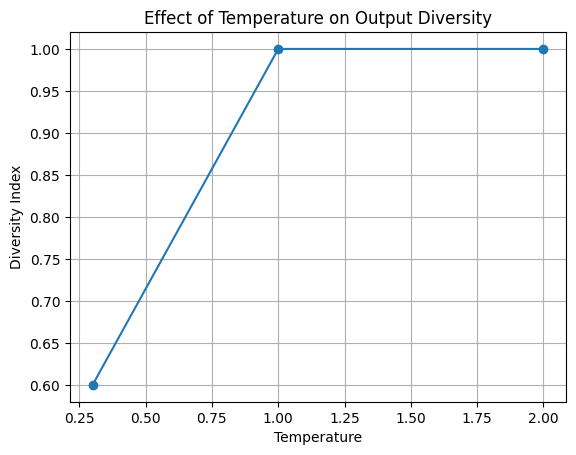

In [ ]:
import matplotlib.pyplot as plt

temps = list(diversity_scores.keys())
scores = list(diversity_scores.values())

plt.plot(temps, scores, marker='o')
plt.xlabel("Temperature")
plt.ylabel("Diversity Index")
plt.title("Effect of Temperature on Output Diversity")
plt.grid(True)
plt.show()


## 🔹 Optional — Interactive Exploration

Launch a simple demo to explore the effect of temperature interactively.


In [ ]:
demo = lab2_build_demo(default_prompt="Describe a sunrise.", default_temperature=1.0)
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://33d647df731507c96a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



## 📊 Results

Summarize your findings briefly:

- Which temperature produced the most diverse outputs?  
- Was your hypothesis supported?  
- Were there any surprises in your observations?



## 💭 Post-Lab Reflection

Answer in 2–3 sentences each:

1. Which temperature produced the most interesting or surprising output?  
2. What trade-off did you observe between creativity and reliability?  
3. How might you use temperature adjustments in a real application?

> ✏️ *Edit this cell and write your answers here.*


---

## 🧠 AI Usage Log

> Use this section to document any generative AI assistance (e.g., ChatGPT, Claude, Copilot) you used while completing this lab or assignment.  
> Be specific — transparency and reflection matter more than the amount of AI use.


| Tool Used | Purpose | Prompt / Context | Verification & Edits |
|------------|----------|------------------|----------------------|
| (e.g., ChatGPT (GPT-5)) | (e.g., debugging, code explanation, idea generation) | (e.g., "Why does my cosine similarity return NaN?") | (e.g., ran tests on sample input, compared with lecture code) |
| (Add rows as needed) | | | |

**Summary (2–3 sentences):**  
Briefly describe what you learned or how AI helped you think through the problem.  
Example: *AI helped me notice an off-by-one error in my indexing. I double-checked by printing intermediate results and confirmed the fix.*

---



In [ ]:
# @title ✅ Run Checks for Lab 2
print("Running basic Lab 2 checks...")

try:
    from course_utils import lab2_measure_diversity
    example = [
        {"temperature": 0.3, "output": "The sun rose slowly."},
        {"temperature": 0.3, "output": "The sun rose slowly."},
        {"temperature": 2.0, "output": "A fiery dawn spilled across the sky."}
    ]
    score = lab2_measure_diversity(example)
    assert isinstance(score, dict)
    assert all(isinstance(k, (float, int)) for k in score.keys())
    print("✅ Diversity metric check passed.")
except Exception as e:
    print("❌ Check failed:", e)


Running basic Lab 2 checks...
✅ Diversity metric check passed.
